# 2026.9.29(화) 22h~

강사님께서 공유해주신 jupyter notebook 파일

In [2]:
import sys
!{sys.executable} -m pip install pandas

In [3]:
import pandas as pd

df = pd.read_csv(
    'pima-indians-diabetes.csv',
    names=[
        "pregnant", "plasma", "pressure", "thickness",
        "insulin", "BMI", "pedigree", "age", "class"
    ]
)

In [4]:
print(df.head())

   pregnant  plasma  pressure  thickness  insulin   BMI  pedigree  age  class
0         6     148        72         35        0  33.6     0.627   50      1
1         1      85        66         29        0  26.6     0.351   31      0
2         8     183        64          0        0  23.3     0.672   32      1
3         1      89        66         23       94  28.1     0.167   21      0
4         0     137        40         35      168  43.1     2.288   33      1


In [5]:
print(df.tail())

     pregnant  plasma  pressure  thickness  insulin   BMI  pedigree  age  \
763        10     101        76         48      180  32.9     0.171   63   
764         2     122        70         27        0  36.8     0.340   27   
765         5     121        72         23      112  26.2     0.245   30   
766         1     126        60          0        0  30.1     0.349   47   
767         1      93        70         31        0  30.4     0.315   23   

     class  
763      0  
764      0  
765      0  
766      1  
767      0  


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pregnant   768 non-null    int64  
 1   plasma     768 non-null    int64  
 2   pressure   768 non-null    int64  
 3   thickness  768 non-null    int64  
 4   insulin    768 non-null    int64  
 5   BMI        768 non-null    float64
 6   pedigree   768 non-null    float64
 7   age        768 non-null    int64  
 8   class      768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [7]:
print(df.describe())

         pregnant      plasma    pressure   thickness     insulin         BMI  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.000000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   30.500000   32.000000   
75%      6.000000  140.250000   80.000000   32.000000  127.250000   36.600000   
max     17.000000  199.000000  122.000000   99.000000  846.000000   67.100000   

         pedigree         age       class  
count  768.000000  768.000000  768.000000  
mean     0.471876   33.240885    0.348958  
std      0.331329   11.760232    0.476951  
min      0.078000   21.000000    0.000000  
25%      0.243750   24.000000    0.000000  
50%   

In [8]:
print(df[['pregnant', 'class']])

     pregnant  class
0           6      1
1           1      0
2           8      1
3           1      0
4           0      1
..        ...    ...
763        10      0
764         2      0
765         5      0
766         1      1
767         1      0

[768 rows x 2 columns]


In [9]:
print(df[['pregnant','class']]
      .groupby(['pregnant'],as_index=False)
      .mean()
      .sort_values(by='pregnant', ascending=True))

    pregnant     class
0          0  0.342342
1          1  0.214815
2          2  0.184466
3          3  0.360000
4          4  0.338235
5          5  0.368421
6          6  0.320000
7          7  0.555556
8          8  0.578947
9          9  0.642857
10        10  0.416667
11        11  0.636364
12        12  0.444444
13        13  0.500000
14        14  1.000000
15        15  1.000000
16        17  1.000000


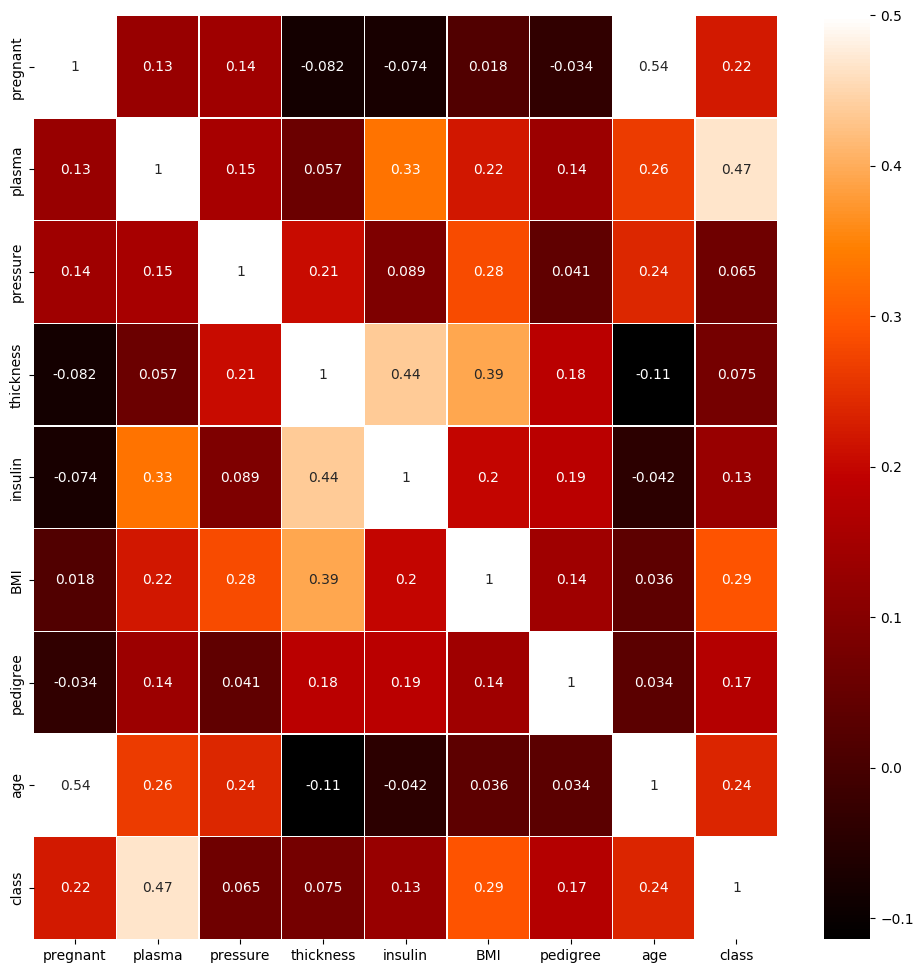

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 12))
sns.heatmap(df.corr(), linewidths=0.1, vmax=0.5, cmap=plt.cm.gist_heat, linecolor='white', annot=True)

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np
import pandas as pd

# seed 값 생성
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터셋 불러오기
df = pd.read_csv(
    'pima-indians-diabetes.csv',
    names=[
        "pregnant", "plasma", "pressure", "thickness",
        "insulin", "BMI", "pedigree", "age", "class"
    ]
)

print(df.head(5))
print(df.info())
print(df.describe())

# 데이터셋을 X(입력)와 Y(출력)로 나누기
X = df.iloc[:, 0:8].values
Y = df.iloc[:, 8].values

# 모델 설정
model = Sequential()
model.add(Input(shape=(8,)))  # 입력값 8개
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 모델 컴파일
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 모델 실행
model.fit(X, Y, epochs=200, batch_size=10)

# 결과 출력
accuracy = model.evaluate(X, Y)[1]
print("\nAccuracy: %.4f" % accuracy)

2026-09-29 22:27:13.403796: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


   pregnant  plasma  pressure  thickness  insulin   BMI  pedigree  age  class
0         6     148        72         35        0  33.6     0.627   50      1
1         1      85        66         29        0  26.6     0.351   31      0
2         8     183        64          0        0  23.3     0.672   32      1
3         1      89        66         23       94  28.1     0.167   21      0
4         0     137        40         35      168  43.1     2.288   33      1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pregnant   768 non-null    int64  
 1   plasma     768 non-null    int64  
 2   pressure   768 non-null    int64  
 3   thickness  768 non-null    int64  
 4   insulin    768 non-null    int64  
 5   BMI        768 non-null    float64
 6   pedigree   768 non-null    float64
 7   age        768 non-null    int64  
 8   class      768 non-null

2026-09-29 22:31:18.817575: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/200
77/77 [==============================] - 18s 32ms/step - loss: 5.6961 - accuracy: 0.4648
Epoch 2/200
77/77 [==============================] - 2s 23ms/step - loss: 1.2160 - accuracy: 0.5859
Epoch 3/200
77/77 [==============================] - 1s 17ms/step - loss: 1.0264 - accuracy: 0.6237
Epoch 4/200
77/77 [==============================] - 1s 14ms/step - loss: 0.9476 - accuracy: 0.6237
Epoch 5/200
77/77 [==============================] - 1s 16ms/step - loss: 0.9041 - accuracy: 0.6250
Epoch 6/200
77/77 [==============================] - 2s 25ms/step - loss: 0.8301 - accuracy: 0.6367
Epoch 7/200
77/77 [==============================] - 1s 10ms/step - loss: 0.7675 - accuracy: 0.6510
Epoch 8/200
77/77 [==============================] - 4s 55ms/step - loss: 0.7572 - accuracy: 0.6510
Epoch 9/200
77/77 [==============================] - 2s 22ms/step - loss: 0.7235 - accuracy: 0.6589
Epoch 10/200
77/77 [==============================] - 1s 11ms/step - loss: 0.7089 - accuracy: 0.653